# Usage
- select the job_gpu_preemtable
- gpu: A100
- instance size: medium


# Camera–LiDAR fusion model on nuScenes

## Goal

This notebook documents the setup of a camera–LiDAR fusion 3D object detector on nuScenes using MMDetection3D.

The objective is to train a BEVFusion model that can be directly compared against the LiDAR-only baseline and used to test whether combining camera and LiDAR information improves detection performance.

## Experimental setting

The fusion model is trained on:
- the nuScenes dataset prepared in the previous notebook
- the same reproducible 20% training-scene subset used for the baseline
- the standard validation split

## Why this fusion model matters

A camera–LiDAR fusion model is important because:
- it tests whether complementary sensor information improves 3D detection
- it allows direct comparison with the LiDAR-only baseline
- it is motivated by the EDA, which suggests that small objects, pedestrian-related classes, and distant objects are likely to benefit from fusion
- BEVFusion provides a unified bird’s-eye-view representation that integrates LiDAR geometry and camera semantics

## Planned outcome

This notebook should:
1. verify the MMDetection3D environment for fusion experiments
2. identify the BEVFusion config to use
3. confirm the subset annotation file paths
4. create a fusion training config for the reduced dataset
5. document the training command
6. prepare the experiment for reproducible execution

In [1]:
# Core libraries
import pandas as pd
import shutil
import matplotlib.pyplot as plt

from pathlib import Path
from typing import List, Tuple, Dict, Final
from pprint import pprint


# OpenMMLab stack
import mmengine
import mmdet
import mmdet3d

In [2]:
# Notebook display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [3]:
import torch

if torch.cuda.is_available():
    print("GPU available")
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

Running on CPU


# Setup and environment

## Define project paths

This notebook uses the same project and dataset paths as the dataset-preparation notebook.

They are defined explicitly here so that the notebook is self-contained and can be run independently.

In [4]:
# Project paths
PROJECT_ROOT = Path.cwd().parent
MMDET3D_ROOT: Final[Path] = PROJECT_ROOT / "external" / "mmdetection3d"

print("PROJECT_ROOT :", PROJECT_ROOT)
print("MMDET3D_ROOT :", MMDET3D_ROOT)

PROJECT_ROOT : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning
MMDET3D_ROOT : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d


## Verify software environment

Before configuring the fusion model, I verify that:
- MMDetection3D is accessible
- the correct Python environment is active
- core libraries are properly installed

This ensures that training will run without unexpected environment issues.

In [5]:
print("mmengine version:", mmengine.__version__)
print("mmdet version   :", mmdet.__version__)
print("mmdet3d version :", mmdet3d.__version__)

mmengine version: 0.10.7
mmdet version   : 3.2.0
mmdet3d version : 1.4.0


The MMDetection3D environment is correctly set up.

Library versions:
- mmengine: 0.10.7
- mmdet: 3.2.0
- mmdet3d: 1.4.0

These versions are compatible and confirm that the training pipeline can be executed.

## Select the model

For the fusion experiment, I use the **BEVFusion** detector, which combines LiDAR point clouds with multi-view camera images in a unified bird’s-eye-view representation for 3D object detection on nuScenes.

**Why BEVFusion**
- explicitly designed for camera–LiDAR fusion on nuScenes
- officially provided in the current MMDetection3D installation
- uses a BEV representation that naturally aligns LiDAR geometry and camera semantics
- enables a direct and fair comparison with the LiDAR-only baseline

**Configuration choice**

I use the official MMDetection3D BEVFusion config:

`bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d.py`

This config defines:
- LiDAR-based feature extraction from point clouds
- multi-view camera feature extraction
- fusion in bird’s-eye-view (BEV) space
- a detection head operating on fused BEV features

# Experiment definition

The default training schedule runs for 20 epochs with periodic validation during training. In practice, this results in a runtime of up to 11 days on a single H100 GPU.

To make experimentation feasible, I use a reduced 20% subset of the dataset and adopt a lighter training schedule to:
- reduce wall-clock training time
- allow multiple experiments (baseline, fusion, ablations)
- still obtain meaningful results

This configuration is suitable for:
- debugging the pipeline
- obtaining a first BEVFusion result quickly
- enabling controlled comparisons with the LiDAR-only baseline

## Define the goal of this experiment

The goal of this experiment is to train a **BEVFusion camera–LiDAR model** on nuScenes and evaluate whether combining modalities improves detection performance compared to the LiDAR-only baseline, particularly in challenging scenarios such as small or distant objects.

## Config file

In [6]:
# Main experiment parameters

MODEL_KEY: str = "bevfusion"
SUBSET_LABEL: str = "40pct"
RUN_NAME: str = "run1"

MAX_EPOCHS: int = 10

GPU_TYPE: str = "a100"

SLURM_QOS: str = "job_gpu_preemptable"
SLURM_TIME: str = "06:00:00" # upper limit
SLURM_MEMORY: str = "48G"

TRAIN_BATCH_SIZE: int = 8 # upper limit
TRAIN_NUM_WORKERS: int = 16

In [7]:
CONFIG: Dict[str, object] = {

    # Experiment
    "experiment_name":
        f"{MODEL_KEY}_nuscenes_{SUBSET_LABEL}_{MAX_EPOCHS}ep_{RUN_NAME}",

    # Model
    "model_name": f"{MODEL_KEY}",

    "base_model_config":
        "bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d.py",

    "experiment_config_file":
        f"{MODEL_KEY}_nuscenes_{SUBSET_LABEL}.py",

    # Dataset
    "subset_label": SUBSET_LABEL,

    "train_ann_file":
        f"subsets/nuscenes_infos_train_{SUBSET_LABEL}.pkl",

    # Training
    "max_epochs": MAX_EPOCHS,
    "val_interval": 1,

    # Dataloader
    "train_batch_size": TRAIN_BATCH_SIZE,
    "train_num_workers": TRAIN_NUM_WORKERS,

    # Hardware
    "gpu_type": GPU_TYPE,

    # SLURM
    "slurm_dir":
        f"{MODEL_KEY}_{SUBSET_LABEL}",

    "slurm_time": SLURM_TIME,
    "slurm_memory": SLURM_MEMORY,
}


pprint(CONFIG)

{'base_model_config': 'bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d.py',
 'experiment_config_file': 'bevfusion_nuscenes_40pct.py',
 'experiment_name': 'bevfusion_nuscenes_40pct_10ep_run1',
 'gpu_type': 'a100',
 'max_epochs': 10,
 'model_name': 'bevfusion',
 'slurm_dir': 'bevfusion_40pct',
 'slurm_memory': '48G',
 'slurm_time': '06:00:00',
 'subset_label': '40pct',
 'train_ann_file': 'subsets/nuscenes_infos_train_40pct.pkl',
 'train_batch_size': 8,
 'train_num_workers': 16,
 'val_interval': 1}


In [8]:
# Change only this name for each independent training run.
# A new experiment folder, checkpoints, logs, and vis_data
# will automatically be created from this name.
EXPERIMENT_NAME: Final[str] = CONFIG["experiment_name"]

print("EXPERIMENT_NAME:", EXPERIMENT_NAME)

EXPERIMENT_NAME: bevfusion_nuscenes_40pct_10ep_run1


## Select the model

I use **BEVFusion** as the fusion detector. It combines LiDAR point clouds with multi-view camera images in a unified bird’s-eye-view representation for 3D object detection on nuScenes.

**Rationale**

- explicitly designed for camera–LiDAR fusion on nuScenes
- supported in the current MMDetection3D installation
- enables direct comparison with the LiDAR-only baseline

In [9]:
MODEL_NAME: Final[str] = CONFIG["model_name"]
BASE_MODEL_CONFIG: Final[str] = CONFIG["base_model_config"]

print("MODEL_NAME       :", MODEL_NAME)
print("BASE_MODEL_CONFIG:", BASE_MODEL_CONFIG)

MODEL_NAME       : bevfusion
BASE_MODEL_CONFIG: bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d.py


## Define the configuration path

I create a separate experiment config instead of modifying the original MMDetection3D config directly. This keeps the repository clean and makes the experiment easier to reproduce.



In [10]:
SOURCE_CONFIG_PATH: Path = (
    MMDET3D_ROOT
    / "projects"
    / "BEVFusion"
    / "configs"
    / BASE_MODEL_CONFIG
)

EXPERIMENT_CONFIG_DIR: Path = MMDET3D_ROOT / "configs" / "my_experiments"
EXPERIMENT_CONFIG_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_CONFIG_PATH: Path = EXPERIMENT_CONFIG_DIR / CONFIG["experiment_config_file"]

print("SOURCE_CONFIG_PATH     :", SOURCE_CONFIG_PATH)
print("SOURCE exists          :", SOURCE_CONFIG_PATH.exists())
print("EXPERIMENT_CONFIG_DIR  :", EXPERIMENT_CONFIG_DIR)
print("EXPERIMENT_CONFIG_PATH :", EXPERIMENT_CONFIG_PATH)

SOURCE_CONFIG_PATH     : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/projects/BEVFusion/configs/bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d.py
SOURCE exists          : True
EXPERIMENT_CONFIG_DIR  : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments
EXPERIMENT_CONFIG_PATH : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments/bevfusion_nuscenes_40pct.py


## Copy the fusion config into the experiment folder

I now create a project-specific copy of the BEVFusion config.

This copied config will be the one modified for the reduced dataset experiment.
The original MMDetection3D config remains untouched.

In [11]:
if EXPERIMENT_CONFIG_PATH.exists():
    print("EXPERIMENT_CONFIG_PATH:", EXPERIMENT_CONFIG_PATH)
    print("\nSafety rule: existing file is not overwritten automatically.")
else:
    shutil.copy2(SOURCE_CONFIG_PATH, EXPERIMENT_CONFIG_PATH)
    print("Copied BEVFusion config to:")
    print(EXPERIMENT_CONFIG_PATH)

print("\nExperiment config exists:", EXPERIMENT_CONFIG_PATH.exists())

EXPERIMENT_CONFIG_PATH: /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments/bevfusion_nuscenes_40pct.py

Safety rule: existing file is not overwritten automatically.

Experiment config exists: True


## Config file settings

In this section, I prepare and modify the MMDetection3D config file for the BEVFusion experiment. All key settings, including the dataset, modalities, training schedule, and data loading parameters, are defined through this configuration.

The main modifications introduce a reduced-budget training setup using a reproducible 20% subset of the nuScenes training data, a shorter training schedule, and adjusted data-loading settings. These changes reduce computational cost while keeping the experiment suitable for analysis and comparison.

The configuration is based on the official BEVFusion nuScenes setup:

- `MODEL_NAME`: `BEVFusion`
- `BASE_MODEL_CONFIG`: `bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d.py`

This configuration combines LiDAR and camera inputs for multimodal 3D object detection and is evaluated under the same reduced-data training conditions as the LiDAR-only baseline.

## Open the config file

In [12]:
with open(EXPERIMENT_CONFIG_PATH, "r") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    print(f"{i+1:03d}: {line.rstrip()}")

001: _base_ = [
002:     '../../projects/BEVFusion/configs/bevfusion_lidar-cam_voxel0075_second_secfpn_8xb4-cyclic-20e_nus-3d.py'
003: ]
004: 
005: train_dataloader = dict(
006:     batch_size=8,
007:     num_workers=16,
008:     persistent_workers=True,
009:     dataset=dict(
010:         dataset=dict(
011:             ann_file='subsets/nuscenes_infos_train_40pct.pkl'
012:         )
013:     )
014: )
015: 
016: val_dataloader = dict(
017:     num_workers=16,
018:     persistent_workers=True
019: )
020: 
021: test_dataloader = dict(
022:     num_workers=16,
023:     persistent_workers=True
024: )
025: 
026: train_cfg = dict(by_epoch=True, max_epochs=10, val_interval=1)
027: 
028: param_scheduler = [
029:     dict(
030:         type='LinearLR',
031:         start_factor=0.33333333,
032:         by_epoch=False,
033:         begin=0,
034:         end=500
035:     ),
036:     dict(
037:         type='CosineAnnealingLR',
038:         begin=0,
039:         T_max=10,
040:         end=10,
041:

## Define override values

I define the main settings that will override the source config for this experiment. These values describe the reduced-budget training setup used in this notebook.

They include adjustments to the training subset, training schedule, and data-loading parameters, ensuring consistency with the LiDAR-only baseline while preserving the official BEVFusion camera–LiDAR setup.

In [13]:
TRAIN_ANN_FILE: Final[str] = CONFIG["train_ann_file"]

MAX_EPOCHS: Final[int] = CONFIG["max_epochs"]
VAL_INTERVAL: Final[int] = CONFIG["val_interval"]
TRAIN_CFG: Final[str] = f"dict(by_epoch=True, max_epochs={MAX_EPOCHS}, val_interval={VAL_INTERVAL})"

# BEVFusion is more memory-intensive than LiDAR-only models
TRAIN_BATCH_SIZE: Final[int] = CONFIG["train_batch_size"]
TRAIN_NUM_WORKERS: Final[int] = CONFIG["train_num_workers"]

print("Override values:")
print("TRAIN_ANN_FILE    :", TRAIN_ANN_FILE)
print("MAX_EPOCHS        :", MAX_EPOCHS)
print("VAL_INTERVAL      :", VAL_INTERVAL)
print("TRAIN_CFG         :", TRAIN_CFG)
print("TRAIN_BATCH_SIZE  :", TRAIN_BATCH_SIZE)
print("TRAIN_NUM_WORKERS :", TRAIN_NUM_WORKERS)

Override values:
TRAIN_ANN_FILE    : subsets/nuscenes_infos_train_40pct.pkl
MAX_EPOCHS        : 10
VAL_INTERVAL      : 1
TRAIN_CFG         : dict(by_epoch=True, max_epochs=10, val_interval=1)
TRAIN_BATCH_SIZE  : 8
TRAIN_NUM_WORKERS : 16


## Write a clear and self-contained experiment config

I define an explicit experiment config that includes all required dataset, modality, and pipeline components, while controlling the key experiment settings through a small set of variables. This includes the reduced training subset, the shorter training schedule, the data-loading parameters, and a checkpoint configuration that saves progress regularly during training.

The configuration is based on an official BEVFusion nuScenes setup and is adapted only where necessary to match the reduced dataset and training constraints.

**Rationale**

- keeps the configuration fully explicit and easy to understand  
- makes the experiment reproducible and self-contained  
- allows quick adjustments through a small set of variables  
- simplifies reuse of the same setup across different models  
- adds regular checkpoints for safer long HPC runs  

In [14]:
CONFIG_TEXT: str = f"""_base_ = [
    '../../projects/BEVFusion/configs/{BASE_MODEL_CONFIG}'
]

train_dataloader = dict(
    batch_size={TRAIN_BATCH_SIZE},
    num_workers={TRAIN_NUM_WORKERS},
    persistent_workers=True,
    dataset=dict(
        dataset=dict(
            ann_file='{TRAIN_ANN_FILE}'
        )
    )
)

val_dataloader = dict(
    num_workers={TRAIN_NUM_WORKERS},
    persistent_workers=True
)

test_dataloader = dict(
    num_workers={TRAIN_NUM_WORKERS},
    persistent_workers=True
)

train_cfg = {TRAIN_CFG}

param_scheduler = [
    dict(
        type='LinearLR',
        start_factor=0.33333333,
        by_epoch=False,
        begin=0,
        end=500
    ),
    dict(
        type='CosineAnnealingLR',
        begin=0,
        T_max={MAX_EPOCHS},
        end={MAX_EPOCHS},
        by_epoch=True,
        eta_min_ratio=1e-4,
        convert_to_iter_based=True
    ),
    dict(
        type='CosineAnnealingMomentum',
        eta_min=0.85 / 0.95,
        begin=0,
        end={MAX_EPOCHS * 0.4},
        by_epoch=True,
        convert_to_iter_based=True
    ),
    dict(
        type='CosineAnnealingMomentum',
        eta_min=1,
        begin={MAX_EPOCHS * 0.4},
        end={MAX_EPOCHS},
        by_epoch=True,
        convert_to_iter_based=True
    )
]

default_hooks = dict(
    checkpoint=dict(
        type='CheckpointHook',
        interval=1,
        save_last=True,
        max_keep_ckpts=3
    )
)
"""

In [15]:
# Create the experiment config only if it does not already exist.
# Using mode "x" prevents accidental overwrite of an existing config.
try:
    with open(EXPERIMENT_CONFIG_PATH, "x") as f:
        f.write(CONFIG_TEXT)

    print("Experiment config written to:")
    print(EXPERIMENT_CONFIG_PATH)

except FileExistsError:
    print("Experiment config already exists:")
    print(EXPERIMENT_CONFIG_PATH)

Experiment config already exists:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments/bevfusion_nuscenes_40pct.py


## Experiment config inspection

In this section, I inspect the final config after applying the base config and the experiment overrides.

In [16]:
from mmengine.config import Config

cfg = Config.fromfile(EXPERIMENT_CONFIG_PATH)

/storage/homefs/ae04q066/.conda/envs/py38_mmdet3d/lib/python3.8/site-packages/mmengine/optim/optimizer/zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \


In [17]:
# High-level overview
for key in cfg.keys():
    print("-", key)

- default_scope
- default_hooks
- env_cfg
- log_processor
- log_level
- load_from
- resume
- custom_imports
- voxel_size
- point_cloud_range
- class_names
- metainfo
- dataset_type
- data_root
- data_prefix
- input_modality
- backend_args
- model
- db_sampler
- train_pipeline
- test_pipeline
- train_dataloader
- val_dataloader
- test_dataloader
- val_evaluator
- test_evaluator
- vis_backends
- visualizer
- lr
- param_scheduler
- train_cfg
- val_cfg
- test_cfg
- optim_wrapper
- auto_scale_lr


In [18]:
# Core experiment settings
print("Model:", cfg.model.type)
print("Dataset:", cfg.dataset_type)
print("Input modality:", cfg.input_modality)

print("\nTraining:")
pprint(cfg.train_cfg)

print("\nBatch size:", cfg.train_dataloader.batch_size)
print("Workers:", cfg.train_dataloader.num_workers)

print("\nTrain subset:")
print(cfg.train_dataloader.dataset.dataset.ann_file)

Model: BEVFusion
Dataset: NuScenesDataset
Input modality: {'use_lidar': True, 'use_camera': True}

Training:
{'by_epoch': True, 'max_epochs': 10, 'val_interval': 1}

Batch size: 8
Workers: 16

Train subset:
subsets/nuscenes_infos_train_40pct.pkl


If model type and dataset type print correctly, they are inherited from the base config.

In [19]:
# Training pipeline
for step in cfg.train_pipeline:
    print(step["type"])

BEVLoadMultiViewImageFromFiles
LoadPointsFromFile
LoadPointsFromMultiSweeps
LoadAnnotations3D
ImageAug3D
BEVFusionGlobalRotScaleTrans
BEVFusionRandomFlip3D
PointsRangeFilter
ObjectRangeFilter
ObjectNameFilter
GridMask
PointShuffle
Pack3DDetInputs


In [20]:
# Model structure
print("Model structure:\n")

for key in cfg.model.keys():
    print("-", key)

Model structure:

- type
- data_preprocessor
- pts_voxel_encoder
- pts_middle_encoder
- pts_backbone
- pts_neck
- bbox_head
- img_backbone
- img_neck
- view_transform
- fusion_layer


In [21]:
pprint(cfg.model.pts_backbone)

{'conv_cfg': {'bias': False, 'type': 'Conv2d'},
 'in_channels': 256,
 'layer_nums': [5, 5],
 'layer_strides': [1, 2],
 'norm_cfg': {'eps': 0.001, 'momentum': 0.01, 'type': 'BN'},
 'out_channels': [128, 256],
 'type': 'SECOND'}


In [22]:
# Optimization
pprint(cfg.optim_wrapper.optimizer)
pprint(cfg.param_scheduler)

{'lr': 0.0002, 'type': 'AdamW', 'weight_decay': 0.01}
[{'begin': 0,
  'by_epoch': False,
  'end': 500,
  'start_factor': 0.33333333,
  'type': 'LinearLR'},
 {'T_max': 10,
  'begin': 0,
  'by_epoch': True,
  'convert_to_iter_based': True,
  'end': 10,
  'eta_min_ratio': 0.0001,
  'type': 'CosineAnnealingLR'},
 {'begin': 0,
  'by_epoch': True,
  'convert_to_iter_based': True,
  'end': 4.0,
  'eta_min': 0.8947368421052632,
  'type': 'CosineAnnealingMomentum'},
 {'begin': 4.0,
  'by_epoch': True,
  'convert_to_iter_based': True,
  'end': 10,
  'eta_min': 1,
  'type': 'CosineAnnealingMomentum'}]


In [23]:
# Checkpoints
pprint(cfg.default_hooks.checkpoint)

{'interval': 1,
 'max_keep_ckpts': 3,
 'save_last': True,
 'type': 'CheckpointHook'}


In [24]:
# Full merged config
print(cfg.pretty_text)

auto_scale_lr = dict(base_batch_size=32, enable=False)
backend_args = None
class_names = [
    'car',
    'truck',
    'construction_vehicle',
    'bus',
    'trailer',
    'barrier',
    'motorcycle',
    'bicycle',
    'pedestrian',
    'traffic_cone',
]
custom_imports = dict(
    allow_failed_imports=False, imports=[
        'projects.BEVFusion.bevfusion',
    ])
data_prefix = dict(
    CAM_BACK='samples/CAM_BACK',
    CAM_BACK_LEFT='samples/CAM_BACK_LEFT',
    CAM_BACK_RIGHT='samples/CAM_BACK_RIGHT',
    CAM_FRONT='samples/CAM_FRONT',
    CAM_FRONT_LEFT='samples/CAM_FRONT_LEFT',
    CAM_FRONT_RIGHT='samples/CAM_FRONT_RIGHT',
    pts='samples/LIDAR_TOP',
    sweeps='sweeps/LIDAR_TOP')
data_root = 'data/nuscenes/'
dataset_type = 'NuScenesDataset'
db_sampler = dict(
    classes=[
        'car',
        'truck',
        'construction_vehicle',
        'bus',
        'trailer',
        'barrier',
        'motorcycle',
        'bicycle',
        'pedestrian',
        'traffic_cone',
    

# Training command

The BEVFusion model can be trained using the following command:

```bash
cd /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d

conda activate py38_mmdet3d

export PYTHONPATH=$PWD:$PYTHONPATH

python tools/train.py configs/my_experiments/bevfusion_nuscenes_20pct.py
```

## Training Time Estimation (nuScenes)

I estimate the full training cost based on a reduced experiment:

- 20% of the dataset  
- 5 epochs  
- observed runtime ≈ **14 hours**

From this:

- **Time per epoch (20%)** ≈ 2.8 hours  
- Scaling to full dataset (×5):
  - **Time per epoch (100%)** ≈ 14 hours  

Assuming a standard **20-epoch schedule**:

- **Total training time (full nuScenes)** ≈  
  **14h × 20 ≈ 280 hours (~12 days of compute)**

---

## Practical Implication (UBELIX)

On UBELIX using preemptable A100 GPUs:

- jobs use a defined walltime (e.g., 4h in this setup)
- jobs may be **preempted at any time** by higher-priority jobs
- interrupted jobs are **automatically requeued**
- training resumes from the **last checkpoint**

Therefore, training proceeds as a sequence of shorter runs:

running → interrupted (timeout or preemption) → requeued → running again → resume from checkpoint

---

## Conclusion

Full nuScenes training with BEVFusion is computationally expensive:

- ≈ **280 hours of GPU compute**
- typically **2–3 weeks wall-clock time** under preemptable scheduling

# Running the fusion training with SLURM

For long BEVFusion training runs on UBELIX, it is safer to submit the experiment through SLURM instead of launching it from a fragile interactive terminal.

**Why this is useful**

Using SLURM makes the training run independent of the local computer state.

This means:
- the job keeps running even if the laptop sleeps
- the job is not interrupted by SSH disconnection
- resource requests are explicit and reproducible

**Strategy**

I create a small SLURM submission script that:
- requests one GPU
- targets a GPU type compatible with the current BEVFusion build
- sets an appropriate wall-time limit
- activates the correct conda environment
- sets `PYTHONPATH` for the BEVFusion project import
- launches the MMDetection3D training command
- can resume from the latest checkpoint if needed

This is important because BEVFusion training is computationally heavier than the LiDAR-only baseline and may require multiple sessions depending on the available GPU and wall-time limit.

## Defining the SLURM script location

I store the SLURM submission script inside the project repository so that the full training procedure remains reproducible and well documented.

This ensures that:
- the exact execution setup is version-controlled together with the code
- the same script can be reused across different experiments
- running conditions (resources, environment, command) are explicitly defined and easy to reproduce

Keeping the SLURM script within the project structure also simplifies debugging and future extensions of the training pipeline.

In [25]:
WORK_DIR: Final[Path] = (
    MMDET3D_ROOT
    / "work_dirs"
    / EXPERIMENT_NAME
)

# TRAIN_CONFIG_PATH: Final[Path] = MMDET3D_ROOT / "configs" / "my_experiments" / "bevfusion_nuscenes_20pct.py"

SLURM_DIR: Final[Path] = PROJECT_ROOT / "slurm"
SLURM_RUN_DIR: Final[Path] = SLURM_DIR / CONFIG["slurm_dir"]
SLURM_RUN_DIR.mkdir(parents=True, exist_ok=True)

SLURM_SCRIPT_PATH: Final[Path] = (
    SLURM_RUN_DIR
    / f"train_{EXPERIMENT_NAME}.slurm"
)

print("WORK_DIR         :", WORK_DIR)
print("TRAIN_CONFIG_PATH:", EXPERIMENT_CONFIG_PATH)
print("SLURM_RUN_DIR    :", SLURM_RUN_DIR)
print("SLURM_SCRIPT_PATH:", SLURM_SCRIPT_PATH)

WORK_DIR         : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/work_dirs/bevfusion_nuscenes_40pct_10ep_run1
TRAIN_CONFIG_PATH: /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/configs/my_experiments/bevfusion_nuscenes_40pct.py
SLURM_RUN_DIR    : /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/bevfusion_40pct
SLURM_SCRIPT_PATH: /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/bevfusion_40pct/train_bevfusion_nuscenes_40pct_10ep_run1.slurm


## Creating a resume-ready SLURM submission script

The script below is designed for a single-GPU UBELIX training run with a 12-hour wall-time limit.

UBELIX requires the GPU type to be specified explicitly in the SLURM request.
For this experiment, I request one A100 GPU, which is compatible with the current BEVFusion setup.

The script supports both:
- a fresh training run if no checkpoint is present
- a resumed training run if a previous checkpoint already exists

https://slurm.schedmd.com/sbatch.html#OPT_signal 

https://hpc-unibe-ch.github.io/runjobs/scheduled-jobs/preemption/ 

**Workflow**
job_gpu_preemptable:  Time Limit = 06:00:00 for a100

- submit job
- job enters **pending**
- job starts **running**

- job is interrupted:
  - either it **reaches the requested time limit** (for example, `4h`)
  - or it is **preempted by a higher-priority job**

- Slurm **terminates the job**
  - state: **TIMEOUT** (if the requested walltime is reached)
  - state: **PREEMPTED** (if killed by the scheduler)

- job is **automatically requeued**
- job returns to **pending**
- job runs again when resources are available
- training **resumes from last checkpoint**

**UBELIX documentation links**
* Partitions & QoS (gpu-invest, preemptable jobs):
https://hpc-unibe-ch.github.io/runjobs/partitions/
* Preemption behavior:
https://hpc-unibe-ch.github.io/runjobs/scheduled-jobs/preemption/
* GPU jobs & limits (A100, CPU/memory per GPU):
https://hpc-unibe-ch.github.io/runjobs/scheduled-jobs/gpus/

In [26]:
SLURM_SCRIPT: str = f"""#!/bin/bash
#
# Description:
#   {CONFIG["model_name"]} training on nuScenes ({SUBSET_LABEL} subset)
#   using {GPU_TYPE.upper()} on UBELIX.
#
# Usage:
#   sbatch {SLURM_SCRIPT_PATH}
#
# Check job:
#   squeue -u $USER
#
# Logs:
#   tail -f {SLURM_RUN_DIR}/job_<JOBID>.out
#   tail -f {SLURM_RUN_DIR}/job_<JOBID>.err
#
#SBATCH --job-name={MODEL_KEY}_{SUBSET_LABEL}
#SBATCH --output={SLURM_RUN_DIR}/job_%j.out
#SBATCH --error={SLURM_RUN_DIR}/job_%j.err

#SBATCH --account=gratis
#SBATCH --partition=gpu-invest
#SBATCH --qos={SLURM_QOS}

#SBATCH --time={SLURM_TIME}
#SBATCH --nodes=1
#SBATCH --ntasks=1

#SBATCH --gres=gpu:{GPU_TYPE}:1
#SBATCH --cpus-per-task={TRAIN_NUM_WORKERS}
#SBATCH --mem={SLURM_MEMORY}

set -eo pipefail

source "$(conda info --base)/etc/profile.d/conda.sh"
conda activate py38_mmdet3d

cd {MMDET3D_ROOT}
export PYTHONPATH="$PWD:$PYTHONPATH"

echo "========================================"
echo "Job ID: $SLURM_JOB_ID"
echo "Host: $(hostname)"
echo "Model: {CONFIG["model_name"]}"
echo "Subset: {SUBSET_LABEL}"
echo "GPU: {GPU_TYPE}"
echo "Max epochs: {MAX_EPOCHS}"
echo "Start time: $(date)"
echo "========================================"

which python
python --version
nvidia-smi

LAST_CHECKPOINT_FILE="{WORK_DIR}/last_checkpoint"

if [ -f "$LAST_CHECKPOINT_FILE" ]; then
    CHECKPOINT_PATH=$(cat "$LAST_CHECKPOINT_FILE")
    echo "Resuming from $CHECKPOINT_PATH"

    python tools/train.py {EXPERIMENT_CONFIG_PATH} \\
        --work-dir {WORK_DIR} \\
        --resume "$CHECKPOINT_PATH"

else
    echo "Starting fresh training"

    python tools/train.py {EXPERIMENT_CONFIG_PATH} \\
        --work-dir {WORK_DIR}
fi
"""

In [27]:
print("TRAIN_CONFIG_PATH exists :", EXPERIMENT_CONFIG_PATH.exists())
print("WORK_DIR exists         :", WORK_DIR.exists())

last_ckpt_path = WORK_DIR / "last_checkpoint"
# epoch_ckpt_path = WORK_DIR / "epoch_5.pth"

print("last_checkpoint exists  :", last_ckpt_path.exists())
# print("epoch_10 exists          :", epoch_ckpt_path.exists())

# if last_ckpt_path.exists():
#     print("last_checkpoint content:")
#     print(last_ckpt_path.read_text().strip())

TRAIN_CONFIG_PATH exists : True
WORK_DIR exists         : True
last_checkpoint exists  : True


In [28]:
# Create the SLURM script only if it does not already exist.
# Using mode "x" prevents accidental overwrite of a working script.
try:
    with open(SLURM_SCRIPT_PATH, "x") as f:
        f.write(SLURM_SCRIPT)

    print("Saved SLURM script to:")
    print(SLURM_SCRIPT_PATH)

except FileExistsError:
    print("SLURM script already exists:")
    print(SLURM_SCRIPT_PATH)

SLURM script already exists:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/bevfusion_40pct/train_bevfusion_nuscenes_40pct_10ep_run1.slurm


## Verifying the generated SLURM script

Before submitting the job, I inspect the generated script to confirm that:
- the requested resources match the current BEVFusion training setup
- the requested GPU type is compatible with the current build
- the environment activation is correct
- `PYTHONPATH` is set correctly for the BEVFusion project import
- the training command points to the correct experiment config
- the script checks for an existing checkpoint and resumes automatically when available

In [29]:
with open(SLURM_SCRIPT_PATH, "r") as f:
    slurm_lines = f.readlines()

for i, line in enumerate(slurm_lines):
    print(f"{i+1:02d}: {line.rstrip()}")

01: #!/bin/bash
02: #
03: # Description:
04: #   bevfusion training on nuScenes (40pct subset)
05: #   using A100 on UBELIX.
06: #
07: # Usage:
08: #   sbatch /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/bevfusion_40pct/train_bevfusion_nuscenes_40pct_10ep_run1.slurm
09: #
10: # Check job:
11: #   squeue -u $USER
12: #
13: # Logs:
14: #   tail -f /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/bevfusion_40pct/job_<JOBID>.out
15: #   tail -f /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/bevfusion_40pct/job_<JOBID>.err
16: #
17: #SBATCH --job-name=bevfusion_40pct
18: #SBATCH --output=/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/bevfusion_40pct/job_%j.out
19: #SBATCH --error=/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/bevfusion_40pct/job_%j.err
20: 
21: #SBATCH --account=gratis
22: #SBATCH --partition=gpu-invest
23: #SBATCH --qos=job_gpu_preemptable
24: 
25: #SBATCH --time=0

## SLURM submission and resume behavior

The training job can be submitted with:

```bash
cd /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning
sbatch slurm/bevfusion_20pct/train_bevfusion_nuscenes_20pct.slurm
```
### GPU available
```bash
sinfo -N -p gpu-invest -o "%N %G %T"
```

### Monitoring  
Useful commands after submission:

```bash
squeue -u ae04q066
```
or
```bash
squeue -u $USER
```

check the effective limits:

```bash
sqos
```
```bash
tail -f /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/bevfusion_20pct/job_<JOBID>.out
```

```bash
cat /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/bevfusion_20pct/job_<JOBID>.err
```

Find your job node
```bash
squeue -u $USER
```

SSH into the node
```bash
ssh gnodeXX
```

Check GPU usage
```bash
nvidia-smi
```

Optional live view:
```bash
watch -n 2 nvidia-smi
```

Exit the node
```bash
exit
```

### Resume behavior  
The SLURM script automatically checks whether the following file exists:

```bash
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/work_dirs/bevfusion_nuscenes_20pct/last_checkpoint
```

This file contains the path to the most recent saved checkpoint.

- if `last_checkpoint` exists, the script reads the checkpoint path stored inside it and resumes training from that checkpoint  
- if `last_checkpoint` does not exist, training starts from scratch  

This makes it possible to continue training across multiple 12-hour SLURM jobs without manually editing the training command each time.

### Cancel job  

```bash
scancel <JOBID>
```

### Benefit  
This execution method is robust to:

- laptop sleep  
- SSH disconnects  
- unstable local network connections  
- wall-time limits requiring multiple job submissions  

In [30]:
print("Submit with:")
print(f"cd {PROJECT_ROOT}")
print(f"sbatch {SLURM_SCRIPT_PATH.relative_to(PROJECT_ROOT)}")

print("\nResume checkpoint file:")

if (WORK_DIR / "last_checkpoint").exists():
    print(WORK_DIR / "last_checkpoint")
else:
    print("No checkpoint found yet.")

print("\nMonitor with:")
print(f"tail -f {SLURM_RUN_DIR}/job_<JOBID>.out")
print(f"cat {SLURM_RUN_DIR}/job_<JOBID>.err")

Submit with:
cd /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning
sbatch slurm/bevfusion_40pct/train_bevfusion_nuscenes_40pct_10ep_run1.slurm

Resume checkpoint file:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/external/mmdetection3d/work_dirs/bevfusion_nuscenes_40pct_10ep_run1/last_checkpoint

Monitor with:
tail -f /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/bevfusion_40pct/job_<JOBID>.out
cat /storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/slurm/bevfusion_40pct/job_<JOBID>.err


# Nuscenes metrics

## Load scalar records and inspect metrics

In this step, I load the scalar metrics from `scalars.json`. This file is stored as one JSON record per line, so I read it line by line and store the records in a list.

In [31]:
# list of run directories
run_names: List[str] = [
    "20260513_130339",
    "20260513_184611",
    "20260514_002313",
    "20260514_111058",
    "20260514_165002",
    "20260514_230302",
    "20260515_112019",
    "20260515_165751",
    "20260515_225616",
    
]

dfs = []

for run_name in run_names:
    run_dir = WORK_DIR / run_name
    scalars_file = run_dir / "vis_data" / "scalars.json"
    
    # Load JSON Lines file → DataFrame
    df = pd.read_json(scalars_file, lines=True)
    
    # add a column to track source
    df["run"] = run_name
    
    dfs.append(df)

# Stack all DataFrames
scalars_df = pd.concat(dfs, ignore_index=True)

# Sort chronologically inside each run
scalars_df = scalars_df.sort_values(
    ["run", "step"],
    na_position="first"
).reset_index(drop=True)

print(scalars_df.shape)
print(scalars_df.head())

(1240, 111)
         lr  data_time    grad_norm        loss  loss_heatmap  \
0       NaN   0.005846          NaN         NaN           NaN   
1  0.000080   0.212844  3766.637715  735.040272    713.522434   
2  0.000093   0.027125    87.357782   24.663905      8.476692   
3  0.000106   0.027148    17.351001   12.699420      2.782444   
4  0.000120   0.028995    15.632166   10.379895      2.584813   

   layer_-1_loss_cls  layer_-1_loss_bbox  matched_ious      time  epoch  \
0                NaN                 NaN           NaN  0.226747    NaN   
1           8.919294           12.598542      0.000129  2.941991    1.0   
2           5.992753           10.194460      0.027710  2.737126    1.0   
3           4.098840            5.818136      0.057761  2.736693    1.0   
4           2.987331            4.807752      0.097141  2.743501    1.0   

    iter   memory  step  \
0    NaN      NaN     1   
1   50.0  42738.0    50   
2  100.0  42875.0   100   
3  150.0  42392.0   150   
4  200.0  4

In [32]:
for i, col in enumerate(scalars_df.columns):
    print(i, col)

0 lr
1 data_time
2 grad_norm
3 loss
4 loss_heatmap
5 layer_-1_loss_cls
6 layer_-1_loss_bbox
7 matched_ious
8 time
9 epoch
10 iter
11 memory
12 step
13 NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_0.5
14 NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_1.0
15 NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_2.0
16 NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_4.0
17 NuScenes metric/pred_instances_3d_NuScenes/car_trans_err
18 NuScenes metric/pred_instances_3d_NuScenes/car_scale_err
19 NuScenes metric/pred_instances_3d_NuScenes/car_orient_err
20 NuScenes metric/pred_instances_3d_NuScenes/car_vel_err
21 NuScenes metric/pred_instances_3d_NuScenes/car_attr_err
22 NuScenes metric/pred_instances_3d_NuScenes/mATE
23 NuScenes metric/pred_instances_3d_NuScenes/mASE
24 NuScenes metric/pred_instances_3d_NuScenes/mAOE
25 NuScenes metric/pred_instances_3d_NuScenes/mAVE
26 NuScenes metric/pred_instances_3d_NuScenes/mAAE
27 NuScenes metric/pred_instances_3d_NuScenes/truck

In [33]:
scalars_df.tail()

,lr,data_time,grad_norm,loss,loss_heatmap,layer_-1_loss_cls,layer_-1_loss_bbox,matched_ious,time,epoch,iter,memory,step,NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_4.0,NuScenes metric/pred_instances_3d_NuScenes/car_trans_err,NuScenes metric/pred_instances_3d_NuScenes/car_scale_err,NuScenes metric/pred_instances_3d_NuScenes/car_orient_err,NuScenes metric/pred_instances_3d_NuScenes/car_vel_err,NuScenes metric/pred_instances_3d_NuScenes/car_attr_err,NuScenes metric/pred_instances_3d_NuScenes/mATE,NuScenes metric/pred_instances_3d_NuScenes/mASE,NuScenes metric/pred_instances_3d_NuScenes/mAOE,NuScenes metric/pred_instances_3d_NuScenes/mAVE,NuScenes metric/pred_instances_3d_NuScenes/mAAE,NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_4.0,NuScenes metric/pred_instances_3d_NuScenes/truck_trans_err,NuScenes metric/pred_instances_3d_NuScenes/truck_scale_err,NuScenes metric/pred_instances_3d_NuScenes/truck_orient_err,NuScenes metric/pred_instances_3d_NuScenes/truck_vel_err,NuScenes metric/pred_instances_3d_NuScenes/truck_attr_err,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_4.0,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_trans_err,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_scale_err,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_orient_err,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_vel_err,NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_attr_err,NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_4.0,NuScenes metric/pred_instances_3d_NuScenes/bus_trans_err,NuScenes metric/pred_instances_3d_NuScenes/bus_scale_err,NuScenes metric/pred_instances_3d_NuScenes/bus_orient_err,NuScenes metric/pred_instances_3d_NuScenes/bus_vel_err,NuScenes metric/pred_instances_3d_NuScenes/bus_attr_err,NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_4.0,NuScenes metric/pred_instances_3d_NuScenes/trailer_trans_err,NuScenes metric/pred_instances_3d_NuScenes/trailer_scale_err,NuScenes metric/pred_instances_3d_NuScenes/trailer_orient_err,NuScenes metric/pred_instances_3d_NuScenes/trailer_vel_err,NuScenes metric/pred_instances_3d_NuScenes/trailer_attr_err,NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_4.0,NuScenes metric/pred_instances_3d_NuScenes/barrier_trans_err,NuScenes metric/pred_instances_3d_NuScenes/barrier_scale_err,NuScenes metric/pred_instances_3d_NuScenes/barrier_orient_err,NuScenes metric/pred_instances_3d_NuScenes/barrier_vel_err,NuScenes metric/pred_instances_3d_NuScenes/barrier_attr_err,NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_0.5,NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_1.0,NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_2.0,NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_4.0,NuScenes metric/pre

## Loss analyis

In this step, I plot the training loss as a function of the training step. This gives a visual overview of how the model learns over time. A decreasing curve indicates that training is progressing correctly.

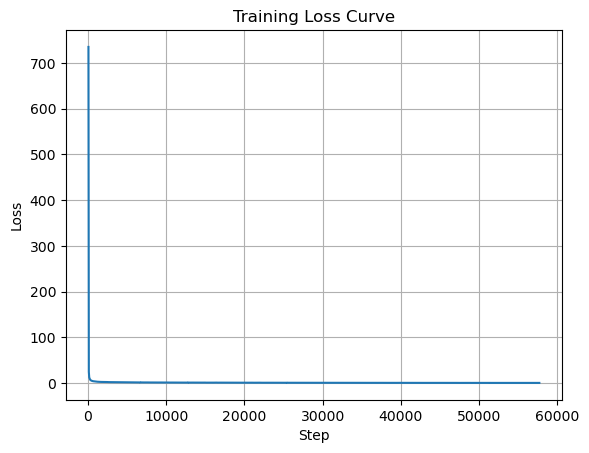

In [34]:
# Sort by step to reconstruct the full training timeline
scalars_df = scalars_df.sort_values("step")

plt.figure()

plt.plot(scalars_df["step"], scalars_df["loss"])

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.grid()

plt.show()

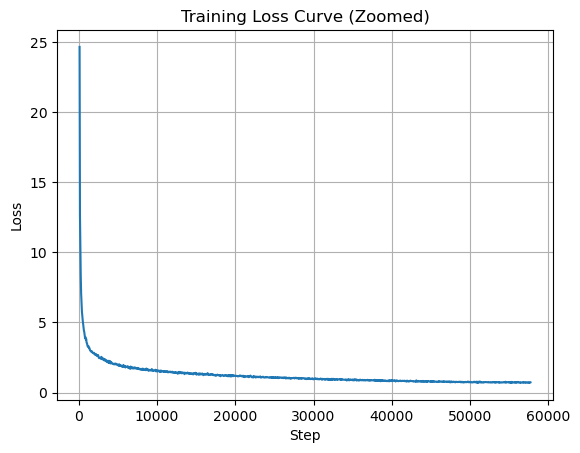

In [35]:
# Sort by step to keep correct order
scalars_df = scalars_df.sort_values("step")

# Filter out very large losses
filtered_df = scalars_df[scalars_df["loss"] < 100]

plt.figure()

plt.plot(filtered_df["step"], filtered_df["loss"])

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve (Zoomed)")

plt.grid()

plt.show()

## List of metrics

In this step, I inspect which validation metrics are present in the scalar records.


In [36]:
# All nuScenes validation metric columns
metrics_cols = [

    # ===================== Car =====================
    "NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/car_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/car_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/car_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/car_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/car_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/car_attr_err",

    # ===================== Global Errors =====================
    "NuScenes metric/pred_instances_3d_NuScenes/mATE",
    "NuScenes metric/pred_instances_3d_NuScenes/mASE",
    "NuScenes metric/pred_instances_3d_NuScenes/mAOE",
    "NuScenes metric/pred_instances_3d_NuScenes/mAVE",
    "NuScenes metric/pred_instances_3d_NuScenes/mAAE",

    # ===================== Truck =====================
    "NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/truck_attr_err",

    # ===================== Construction Vehicle =====================
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/construction_vehicle_attr_err",

    # ===================== Bus =====================
    "NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bus_attr_err",

    # ===================== Trailer =====================
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/trailer_attr_err",

    # ===================== Barrier =====================
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/barrier_attr_err",

    # ===================== Motorcycle =====================
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/motorcycle_attr_err",

    # ===================== Bicycle =====================
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/bicycle_attr_err",

    # ===================== Pedestrian =====================
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/pedestrian_attr_err",

    # ===================== Traffic Cone =====================
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_AP_dist_0.5",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_AP_dist_1.0",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_AP_dist_2.0",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_AP_dist_4.0",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_trans_err",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_scale_err",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_orient_err",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_vel_err",
    "NuScenes metric/pred_instances_3d_NuScenes/traffic_cone_attr_err",

    # ===================== Summary =====================
    "NuScenes metric/pred_instances_3d_NuScenes/NDS",
    "NuScenes metric/pred_instances_3d_NuScenes/mAP",
]

In [37]:
prefix = "NuScenes metric/pred_instances_3d_NuScenes/"

rename_cols = {
    # Summary metrics
    prefix + "NDS": "NDS",
    prefix + "mAP": "mAP",
    prefix + "mATE": "mATE",
    prefix + "mASE": "mASE",
    prefix + "mAOE": "mAOE",
    prefix + "mAVE": "mAVE",
    prefix + "mAAE": "mAAE",
}

classes = [
    "car",
    "truck",
    "construction_vehicle",
    "bus",
    "trailer",
    "barrier",
    "motorcycle",
    "bicycle",
    "pedestrian",
    "traffic_cone",
]

for cls in classes:
    rename_cols[prefix + f"{cls}_AP_dist_0.5"] = f"{cls}_AP_0.5"
    rename_cols[prefix + f"{cls}_AP_dist_1.0"] = f"{cls}_AP_1.0"
    rename_cols[prefix + f"{cls}_AP_dist_2.0"] = f"{cls}_AP_2.0"
    rename_cols[prefix + f"{cls}_AP_dist_4.0"] = f"{cls}_AP_4.0"

    rename_cols[prefix + f"{cls}_trans_err"] = f"{cls}_ATE"
    rename_cols[prefix + f"{cls}_scale_err"] = f"{cls}_ASE"
    rename_cols[prefix + f"{cls}_orient_err"] = f"{cls}_AOE"
    rename_cols[prefix + f"{cls}_vel_err"] = f"{cls}_AVE"
    rename_cols[prefix + f"{cls}_attr_err"] = f"{cls}_AAE"
    
# Keep only metrics + useful identifiers
metrics_df = scalars_df[["run", "epoch", "step"] + metrics_cols].copy()

# Rename columns
metrics_df = metrics_df.rename(columns=rename_cols)

# Keep only validation/evaluation rows
metrics_df = metrics_df.dropna(subset=["NDS", "mAP"]).copy()

print(metrics_df.shape)
metrics_df.head(20)


(9, 100)


,run,epoch,step,car_AP_0.5,car_AP_1.0,car_AP_2.0,car_AP_4.0,car_ATE,car_ASE,car_AOE,car_AVE,car_AAE,mATE,mASE,mAOE,mAVE,mAAE,truck_AP_0.5,truck_AP_1.0,truck_AP_2.0,truck_AP_4.0,truck_ATE,truck_ASE,truck_AOE,truck_AVE,truck_AAE,construction_vehicle_AP_0.5,construction_vehicle_AP_1.0,construction_vehicle_AP_2.0,construction_vehicle_AP_4.0,construction_vehicle_ATE,construction_vehicle_ASE,construction_vehicle_AOE,construction_vehicle_AVE,construction_vehicle_AAE,bus_AP_0.5,bus_AP_1.0,bus_AP_2.0,bus_AP_4.0,bus_ATE,bus_ASE,bus_AOE,bus_AVE,bus_AAE,trailer_AP_0.5,trailer_AP_1.0,trailer_AP_2.0,trailer_AP_4.0,trailer_ATE,trailer_ASE,trailer_AOE,trailer_AVE,trailer_AAE,barrier_AP_0.5,barrier_AP_1.0,barrier_AP_2.0,barrier_AP_4.0,barrier_ATE,barrier_ASE,barrier_AOE,barrier_AVE,barrier_AAE,motorcycle_AP_0.5,motorcycle_AP_1.0,motorcycle_AP_2.0,motorcycle_AP_4.0,motorcycle_ATE,motorcycle_ASE,motorcycle_AOE,motorcycle_AVE,motorcycle_AAE,bicycle_AP_0.5,bicycle_AP_1.0,bicycle_AP_2.0,bicycle_AP_4.0,bicycle_ATE,bicycle_ASE,bicycle_AOE,bicycle_AVE,bicycle_AAE,pedestrian_AP_0.5,pedestrian_AP_1.0,pedestrian_AP_2.0,pedestrian_AP_4.0,pedestrian_ATE,pedestrian_ASE,pedestrian_AOE,pedestrian_AVE,pedestrian_AAE,traffic_cone_AP_0.5,traffic_cone_AP_1.0,traffic_cone_AP_2.0,traffic_cone_AP_4.0,traffic_cone_ATE,traffic_cone_ASE,traffic_cone_AOE,traffic_cone_AVE,traffic_cone_AAE,NDS,mAP
0,20260513_130339,NaN,1,0.6473,0.7887,0.8393,0.8606,0.2267,0.1969,0.2445,1.6298,0.3884,0.4420,0.3433,0.9961,1.2328,0.3322,0.1349,0.3186,0.4345,0.5050,0.4973,0.3369,0.4669,1.4694,0.4242,0.0001,0.0571,0.1768,0.2521,0.8517,0.5062,1.7131,0.1579,0.3290,0.0867,0.3046,0.4858,0.5519,0.5941,0.2620,1.4198,2.8752,0.6887,0.0000,0.0125,0.1285,0.2468,0.9942,0.4111,1.6156,0.6919,0.2965,0.2939,0.4601,0.5077,0.5354,0.3196,0.3250,0.2281,NaN,NaN,0.2638,0.3766,0.3957,0.4085,0.3200,0.3666,1.1900,1.8702,0.2579,0.2782,0.3389,0.3454,0.3758,0.2519,0.3442,1.4065,0.6185,0.0728,0.7527,0.7769,0.7948,0.8131,0.1797,0.2960,0.6802,0.5492,0.1999,0.6283,0.6498,0.6784,0.7303,0.1849,0.3882,NaN,NaN,NaN,0.404098,0.430907
134,20260513_184611,NaN,2,0.7169,0.8342,0.8736,0.8881,0.2002,0.1800,0.1634,1.2066,0.2707,0.3770,0.3106,0.8207,1.0523,0.2735,0.1483,0.3359,0.4343,0.4810,0.4776,0.2966,0.3401,1.2887,0.3851,0.0036,0.0696,0.1906,0.2797,0.7945,0.4642,1.5217,0.1492,0.3191,0.1399,0.4258,0.5653,0.6536,0.5262,0.2458,0.8158,2.5856,0.5695,0.0135,0.1152,0.1992,0.2797,0.6711,0.3080,1.3464,0.7329,0.3082,0.3744,0.5176,0.5660,0.5862,0.2740,0.3417,0.1018,NaN,NaN,0.3621,0.5018,0.5211,0.5388,0.2928,0.2945,1.1460,1.3686,0.1778,0.3952,0.4415,0.4512,0.4701,0.2161,0.3248,1.4434,0.7117,0.0306,0.8012,0.8195,0.8340,0.8479,0.1552,0.2867,0.5081,0.3747,0.1267,0.6694,0.6851,0.7112,0.7520,0.1628,0.3637,NaN,NaN,NaN,0.465497,0.487361
265,20260514_002313,NaN,3,0.7172,0.8373,0.8753,0.8885,0.1970,0.1838,0.1345,0.5794,0.2108,0.3501,0.3032,0.6729,0.7627,0.2271,0.2228,0.3870,0.4793,0.5333,0.4032,0.2730,0.2668,0.6183,0.2508,0.0055,0.1208,0.2488,0.3531,0.7536,0.4689,1.3758,0.1566,0.3198,0.1860,0.4256,0.5878,0.6854,0.4917,0.2542,0.4852,2.4085,0.3946,0.0346,0.1728,0.3091,0.4061,0.6512,0.3014,1.2693,0.7400,0.2806,0.4153,0.5408,0.5823,0.6038,0.2471,0.3124,0.0798,NaN,NaN,0.4747,0.6216,0.6440,0.6603,0.2558,0.2850,0.8819,0.9191,0.2216,0.4138,0.4577,0.4635,0.4819,0.2085,0.2884,1.1151,0.3446,0.0154,0.8144,0.8286,0.8406,0.8531,0.1448,0.2898,0.4474,0.3351,0.1232,0.6789,0.6945,0.7167,0.7551,0.1479,0.3748,NaN,NaN,NaN,0.531125,0.525441
407,20260514_111058,NaN,4,0.7369,0.8457,0.8825,0.8955,0.1903,0.1768,0.1370,0.5095,0.2036,0.3359,0.2975,0.5839,0.5323,0.2021,0.2621,0.4364,0.5275,0.5779,0.3852,0.2656,0.2041,0.4925,0.2350,0.0063,0.1368,0.2578,0.3459,0.7200,0.4392,1.2912,0.1449,0.3453,0.2342,0.4990,0.6626,0.7390,0.4581,0.2209,0.2733,1.2212,0.2488,0.0457,0.1743,0.3233,0.4208,0.6144,0.3215,1.2693,0.4481,0.2402,0.4498,0.5735,0.6143,0.6331,0.2404,0.3069,0.0730,NaN,NaN,0.4689,0.6050,0.6240,0.6352,0.2461,0.2788,0.6850,0.8907,0.2178,0.3931,0.4524,0.4607,0.4698,0.2273,0.2924,0.8754,

**Observations**: 

I’m not seeing a bug with checkpointing or resume, those are working fine. The missing NDS values happen because of the Slurm time limit.

Each epoch runs: training → save checkpoint → validation. Sometimes the job hits the 6-hour limit after training and saving, but before validation finishes. When that happens, the checkpoint exists, but no NDS is logged.

When I resume, training continues normally and validation completes for a later epoch. That’s why I only get NDS for epochs 1, 3, and 5—epochs 2 and 4 were interrupted during validation.

## NDS and mAP

In this step, I plot the NDS (nuScenes Detection Score) over the validation steps. This shows how the model performance improves across epochs. Unlike training loss, this curve reflects actual detection quality on the validation set.

Metrics:
* ```NDS``` (nuScenes Detection Score) is the main benchmark metric that combines detection accuracy and prediction quality into a single score. It includes mAP together with five true-positive metrics: translation error (mATE), scale error (mASE), orientation error (mAOE), velocity error (mAVE), and attribute error (mAAE). While mAP measures whether objects are detected and approximately localized, NDS additionally evaluates how accurate the predicted 3D box position, size, orientation, motion, and semantic attributes are.
* nuScenes ```mAP``` measures how well a model detects objects across different localization accuracies. A prediction is considered correct if the predicted object center is within one of four distance thresholds (0.5m, 1m, 2m, 4m) from the ground-truth center on the ground plane. AP is computed for each class and threshold, and the final mAP is the average over all classes and thresholds. Using multiple thresholds allows nuScenes to evaluate both object detection capability and localization precision.

**Source**: https://github.com/nutonomy/nuscenes-devkit/blob/master/python-sdk/nuscenes/eval/detection/README.md



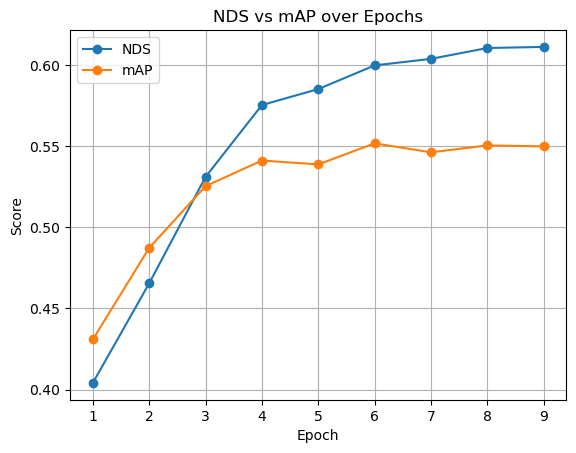

In [38]:
# Plot both curves
plt.plot(metrics_df["step"], metrics_df["NDS"], marker="o", label="NDS")
plt.plot(metrics_df["step"], metrics_df["mAP"], marker="o", label="mAP")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("NDS vs mAP over Epochs")

plt.legend()
plt.grid()

plt.show()

**Observations:** Both mAP and NDS increase steadily across epochs, indicating improved detection performance during training. While mAP begins to plateau after later epochs, NDS continues to improve slightly, suggesting that the model is still refining detection quality metrics such as localization, orientation, velocity, and attribute prediction.

**Comparison:** The BEVFusion model achieves higher mean Average Precision (mAP) and NuScenes Detection Score (NDS) than the LiDAR-only baseline across all epochs. BEVFusion also converges faster, with both metrics approaching a plateau after around epoch 5, while the baseline continues to improve more gradually. The performance gap is particularly visible for mAP, suggesting that combining LiDAR and camera information improves overall object detection performance compared to using LiDAR only.

## Global errors
* ```mATE``` (mean Average Translation Error) measures the average localization error between the predicted and ground-truth object centers on the ground plane, in meters. Lower values indicate more accurate object positioning.
* ```mASE``` (mean Average Scale Error) measures the error in predicted object size using 1 − IoU after aligning translation and orientation. Lower values indicate more accurate object dimensions.
* ```mAOE``` (mean Average Orientation Error) measures the average difference in yaw angle between predicted and ground-truth bounding boxes, in radians. Lower values indicate more accurate orientation estimation.
* ```mAVE``` (mean Average Velocity Error) measures the average error in predicted object velocity, computed as the L2 distance between predicted and ground-truth velocities in m/s. Lower values indicate more accurate motion estimation.
* ```mAAE``` (mean Average Attribute Error) measures the error in semantic attribute prediction, defined as 1 − attribute classification accuracy. Lower values indicate better attribute prediction (e.g., moving, parked, standing).

**Source:** https://mmdetection3d.readthedocs.io/en/latest/advanced_guides/datasets/nuscenes.html

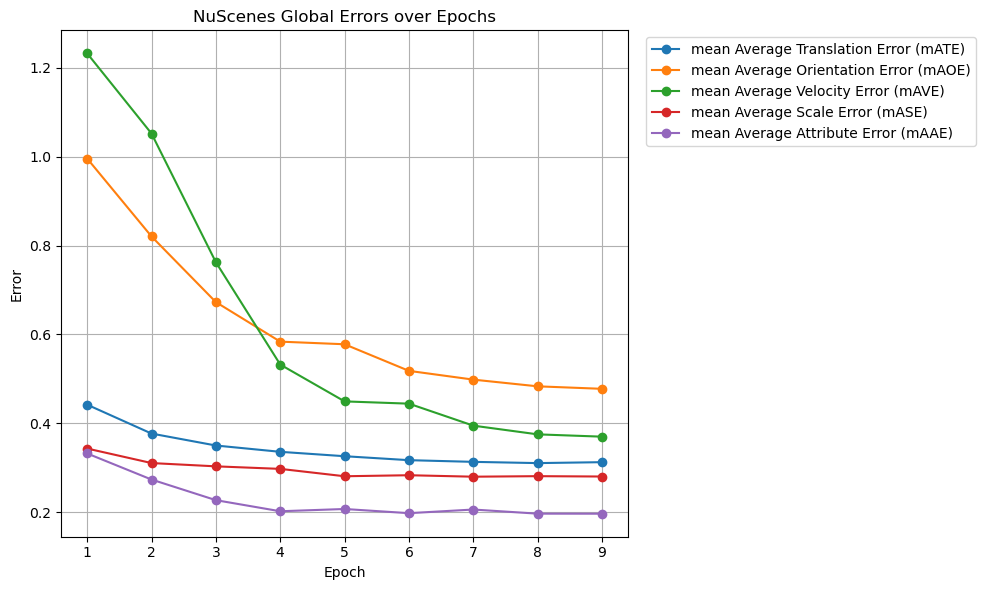

In [39]:
plt.figure(figsize=(10, 6))

# Plot curves
plt.plot(metrics_df["step"], metrics_df["mATE"], marker="o",
         label="mean Average Translation Error (mATE)")

plt.plot(metrics_df["step"], metrics_df["mAOE"], marker="o",
         label="mean Average Orientation Error (mAOE)")

plt.plot(metrics_df["step"], metrics_df["mAVE"], marker="o",
         label="mean Average Velocity Error (mAVE)")

plt.plot(metrics_df["step"], metrics_df["mASE"], marker="o",
         label="mean Average Scale Error (mASE)")

plt.plot(metrics_df["step"], metrics_df["mAAE"], marker="o",
         label="mean Average Attribute Error (mAAE)")

# Labels
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("NuScenes Global Errors over Epochs")

# Put legend outside
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid()

# Prevent clipping
plt.tight_layout()

plt.show()

In [40]:
last_row = metrics_df.iloc[-1]

print("Global detection metrics:")
print(f"NuScenes Detection Score (NDS)       : {last_row['NDS']:.4f}")
print(f"mean Average Precision (mAP)         : {last_row['mAP']:.4f}")

print("\nGlobal error metrics:")
print(f"mean Average Translation Error (mATE): {last_row['mATE']:.4f}")
print(f"mean Average Scale Error (mASE)      : {last_row['mASE']:.4f}")
print(f"mean Average Orientation Error (mAOE): {last_row['mAOE']:.4f}")
print(f"mean Average Velocity Error (mAVE)   : {last_row['mAVE']:.4f}")
print(f"mean Average Attribute Error (mAAE)  : {last_row['mAAE']:.4f}")


Global detection metrics:
NuScenes Detection Score (NDS)       : 0.6113
mean Average Precision (mAP)         : 0.5499

Global error metrics:
mean Average Translation Error (mATE): 0.3126
mean Average Scale Error (mASE)      : 0.2803
mean Average Orientation Error (mAOE): 0.4777
mean Average Velocity Error (mAVE)   : 0.3700
mean Average Attribute Error (mAAE)  : 0.1966


**Observations:** All error metrics generally decrease during training, indicating improved detection quality over epochs. The largest improvements occur in the early epochs, while the curves become more stable after epoch 5. Orientation error (mAOE) shows the strongest improvement, whereas scale error (mASE) changes more gradually.

**Comparison:** BEVFusion achieves lower translation error (mATE) than the LiDAR-only baseline, indicating improved object localization. However, the LiDAR-only baseline achieves lower scale error (mASE), orientation error (mAOE), velocity error (mAVE), and attribute error (mAAE). The largest difference is observed for velocity error, where the baseline performs noticeably better. Despite these higher regression errors, BEVFusion still achieves higher mean Average Precision (mAP) and NuScenes Detection Score (NDS), suggesting improved overall detection performance.

In [41]:
metrics_df.head(9)

,run,epoch,step,car_AP_0.5,car_AP_1.0,car_AP_2.0,car_AP_4.0,car_ATE,car_ASE,car_AOE,car_AVE,car_AAE,mATE,mASE,mAOE,mAVE,mAAE,truck_AP_0.5,truck_AP_1.0,truck_AP_2.0,truck_AP_4.0,truck_ATE,truck_ASE,truck_AOE,truck_AVE,truck_AAE,construction_vehicle_AP_0.5,construction_vehicle_AP_1.0,construction_vehicle_AP_2.0,construction_vehicle_AP_4.0,construction_vehicle_ATE,construction_vehicle_ASE,construction_vehicle_AOE,construction_vehicle_AVE,construction_vehicle_AAE,bus_AP_0.5,bus_AP_1.0,bus_AP_2.0,bus_AP_4.0,bus_ATE,bus_ASE,bus_AOE,bus_AVE,bus_AAE,trailer_AP_0.5,trailer_AP_1.0,trailer_AP_2.0,trailer_AP_4.0,trailer_ATE,trailer_ASE,trailer_AOE,trailer_AVE,trailer_AAE,barrier_AP_0.5,barrier_AP_1.0,barrier_AP_2.0,barrier_AP_4.0,barrier_ATE,barrier_ASE,barrier_AOE,barrier_AVE,barrier_AAE,motorcycle_AP_0.5,motorcycle_AP_1.0,motorcycle_AP_2.0,motorcycle_AP_4.0,motorcycle_ATE,motorcycle_ASE,motorcycle_AOE,motorcycle_AVE,motorcycle_AAE,bicycle_AP_0.5,bicycle_AP_1.0,bicycle_AP_2.0,bicycle_AP_4.0,bicycle_ATE,bicycle_ASE,bicycle_AOE,bicycle_AVE,bicycle_AAE,pedestrian_AP_0.5,pedestrian_AP_1.0,pedestrian_AP_2.0,pedestrian_AP_4.0,pedestrian_ATE,pedestrian_ASE,pedestrian_AOE,pedestrian_AVE,pedestrian_AAE,traffic_cone_AP_0.5,traffic_cone_AP_1.0,traffic_cone_AP_2.0,traffic_cone_AP_4.0,traffic_cone_ATE,traffic_cone_ASE,traffic_cone_AOE,traffic_cone_AVE,traffic_cone_AAE,NDS,mAP
0,20260513_130339,NaN,1,0.6473,0.7887,0.8393,0.8606,0.2267,0.1969,0.2445,1.6298,0.3884,0.4420,0.3433,0.9961,1.2328,0.3322,0.1349,0.3186,0.4345,0.5050,0.4973,0.3369,0.4669,1.4694,0.4242,0.0001,0.0571,0.1768,0.2521,0.8517,0.5062,1.7131,0.1579,0.3290,0.0867,0.3046,0.4858,0.5519,0.5941,0.2620,1.4198,2.8752,0.6887,0.0000,0.0125,0.1285,0.2468,0.9942,0.4111,1.6156,0.6919,0.2965,0.2939,0.4601,0.5077,0.5354,0.3196,0.3250,0.2281,NaN,NaN,0.2638,0.3766,0.3957,0.4085,0.3200,0.3666,1.1900,1.8702,0.2579,0.2782,0.3389,0.3454,0.3758,0.2519,0.3442,1.4065,0.6185,0.0728,0.7527,0.7769,0.7948,0.8131,0.1797,0.2960,0.6802,0.5492,0.1999,0.6283,0.6498,0.6784,0.7303,0.1849,0.3882,NaN,NaN,NaN,0.404098,0.430907
134,20260513_184611,NaN,2,0.7169,0.8342,0.8736,0.8881,0.2002,0.1800,0.1634,1.2066,0.2707,0.3770,0.3106,0.8207,1.0523,0.2735,0.1483,0.3359,0.4343,0.4810,0.4776,0.2966,0.3401,1.2887,0.3851,0.0036,0.0696,0.1906,0.2797,0.7945,0.4642,1.5217,0.1492,0.3191,0.1399,0.4258,0.5653,0.6536,0.5262,0.2458,0.8158,2.5856,0.5695,0.0135,0.1152,0.1992,0.2797,0.6711,0.3080,1.3464,0.7329,0.3082,0.3744,0.5176,0.5660,0.5862,0.2740,0.3417,0.1018,NaN,NaN,0.3621,0.5018,0.5211,0.5388,0.2928,0.2945,1.1460,1.3686,0.1778,0.3952,0.4415,0.4512,0.4701,0.2161,0.3248,1.4434,0.7117,0.0306,0.8012,0.8195,0.8340,0.8479,0.1552,0.2867,0.5081,0.3747,0.1267,0.6694,0.6851,0.7112,0.7520,0.1628,0.3637,NaN,NaN,NaN,0.465497,0.487361
265,20260514_002313,NaN,3,0.7172,0.8373,0.8753,0.8885,0.1970,0.1838,0.1345,0.5794,0.2108,0.3501,0.3032,0.6729,0.7627,0.2271,0.2228,0.3870,0.4793,0.5333,0.4032,0.2730,0.2668,0.6183,0.2508,0.0055,0.1208,0.2488,0.3531,0.7536,0.4689,1.3758,0.1566,0.3198,0.1860,0.4256,0.5878,0.6854,0.4917,0.2542,0.4852,2.4085,0.3946,0.0346,0.1728,0.3091,0.4061,0.6512,0.3014,1.2693,0.7400,0.2806,0.4153,0.5408,0.5823,0.6038,0.2471,0.3124,0.0798,NaN,NaN,0.4747,0.6216,0.6440,0.6603,0.2558,0.2850,0.8819,0.9191,0.2216,0.4138,0.4577,0.4635,0.4819,0.2085,0.2884,1.1151,0.3446,0.0154,0.8144,0.8286,0.8406,0.8531,0.1448,0.2898,0.4474,0.3351,0.1232,0.6789,0.6945,0.7167,0.7551,0.1479,0.3748,NaN,NaN,NaN,0.531125,0.525441
407,20260514_111058,NaN,4,0.7369,0.8457,0.8825,0.8955,0.1903,0.1768,0.1370,0.5095,0.2036,0.3359,0.2975,0.5839,0.5323,0.2021,0.2621,0.4364,0.5275,0.5779,0.3852,0.2656,0.2041,0.4925,0.2350,0.0063,0.1368,0.2578,0.3459,0.7200,0.4392,1.2912,0.1449,0.3453,0.2342,0.4990,0.6626,0.7390,0.4581,0.2209,0.2733,1.2212,0.2488,0.0457,0.1743,0.3233,0.4208,0.6144,0.3215,1.2693,0.4481,0.2402,0.4498,0.5735,0.6143,0.6331,0.2404,0.3069,0.0730,NaN,NaN,0.4689,0.6050,0.6240,0.6352,0.2461,0.2788,0.6850,0.8907,0.2178,0.3931,0.4524,0.4607,0.4698,0.2273,0.2924,0.8754,

In [42]:
classes = [
    "car", "truck", "bus", "trailer", "construction_vehicle",
    "pedestrian", "motorcycle", "bicycle", "traffic_cone", "barrier"
]

last = metrics_df.iloc[-1]

per_class_df = pd.DataFrame(index=classes)

# Average Precision
per_class_df["Average Precision (AP)"] = [
    last[[f"{cls}_AP_0.5", f"{cls}_AP_1.0", f"{cls}_AP_2.0", f"{cls}_AP_4.0"]].mean()
    for cls in classes
]

# Error metrics
per_class_df["Translation Error (ATE)"] = [last[f"{cls}_ATE"] for cls in classes]
per_class_df["Scale Error (ASE)"] = [last[f"{cls}_ASE"] for cls in classes]
per_class_df["Orientation Error (AOE)"] = [last[f"{cls}_AOE"] for cls in classes]
per_class_df["Velocity Error (AVE)"] = [last[f"{cls}_AVE"] for cls in classes]
per_class_df["Attribute Error (AAE)"] = [last[f"{cls}_AAE"] for cls in classes]

per_class_df = per_class_df.round(3)

per_class_df = per_class_df.sort_values(
    by="Average Precision (AP)",
    ascending=False
)
per_class_df

,Average Precision (AP),Translation Error (ATE),Scale Error (ASE),Orientation Error (AOE),Velocity Error (AVE),Attribute Error (AAE)
pedestrian,0.843,0.131,0.290,0.395,0.250,0.106
car,0.841,0.182,0.167,0.087,0.371,0.184
traffic_cone,0.720,0.126,0.363,NaN,NaN,NaN
motorcycle,0.625,0.232,0.253,0.460,0.562,0.243
bus,0.560,0.389,0.214,0.154,0.788,0.240
barrier,0.512,0.218,0.290,0.054,NaN,NaN
truck,0.482,0.356,0.226,0.131,0.328,0.237
bicycle,0.467,0.195,0.266,0.815,0.217,0.013
trailer,0.256,0.544,0.284,1.147,0.300,0.213
construction_vehicle,0.194,0.752,0.450,1.056,0.144,0.338


**Observations:** Detection performance varies significantly across object classes. Cars and pedestrians achieve the highest Average Precision (AP) values, indicating strong detection performance for common and well-represented objects. In contrast, trailers and construction vehicles remain more difficult to detect, with lower AP and higher translation error (ATE) and orientation error (AOE). Velocity error (AVE) is particularly high for buses and motorcycles, while bicycles show relatively large orientation errors. Traffic cones and barriers do not include orientation, velocity, or attribute metrics because these properties are not defined for these object types in the nuScenes evaluation.

# Export the data

In [43]:
# Export cleaned metrics for final comparison notebook

OUTPUT_DIR: Final[Path] = (
    PROJECT_ROOT / "results" / "final_metrics"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Add experiment metadata
metrics_df["model"] = CONFIG["model_name"]
metrics_df["subset"] = CONFIG["subset_label"]
metrics_df["experiment_name"] = CONFIG["experiment_name"]
metrics_df["gpu_type"] = CONFIG["gpu_type"]
metrics_df["max_epochs"] = CONFIG["max_epochs"]

# Output file
OUTPUT_FILE: Final[Path] = (
    OUTPUT_DIR /
    f"{CONFIG['experiment_name']}_metrics.csv"
)

# Save cleaned metrics
metrics_df.to_csv(OUTPUT_FILE, index=False)

print("Saved metrics dataframe:")
print(OUTPUT_FILE)

Saved metrics dataframe:
/storage/homefs/ae04q066/projects/nuscenes-multimodal-learning/results/final_metrics/bevfusion_nuscenes_40pct_10ep_run1_metrics.csv
